In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("../data/raw/smart_meter_readings.csv")

In [3]:
df.head()

,meter_id,timestamp,energy_kwh,voltage,current,power_factor
0,M0001,2026-01-01 00:00:00,1.239,230.96,2.05,0.858
1,M0001,2026-01-01 00:15:00,1.447,233.03,3.20,0.853
2,M0001,2026-01-01 00:30:00,1.318,228.42,2.22,0.893
3,M0001,2026-01-01 00:45:00,1.014,232.85,1.82,0.936
4,M0001,2026-01-01 01:00:00,1.341,227.77,2.50,0.914


In [4]:
df.shape

(288000, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   meter_id      288000 non-null  str    
 1   timestamp     288000 non-null  str    
 2   energy_kwh    288000 non-null  float64
 3   voltage       288000 non-null  float64
 4   current       288000 non-null  float64
 5   power_factor  288000 non-null  float64
dtypes: float64(4), str(2)
memory usage: 13.2 MB


In [6]:
df.describe()

,energy_kwh,voltage,current,power_factor
count,288000.000000,288000.000000,288000.000000,288000.000000
mean,3.119527,229.997656,6.239267,0.919923
std,1.558674,2.998826,3.274908,0.040436
min,0.237000,215.850000,0.540000,0.850000
25%,1.913000,227.970000,3.750000,0.885000
50%,2.771000,230.000000,5.550000,0.920000
75%,4.115000,232.020000,8.140000,0.955000
max,8.567000,243.830000,20.870000,0.990000


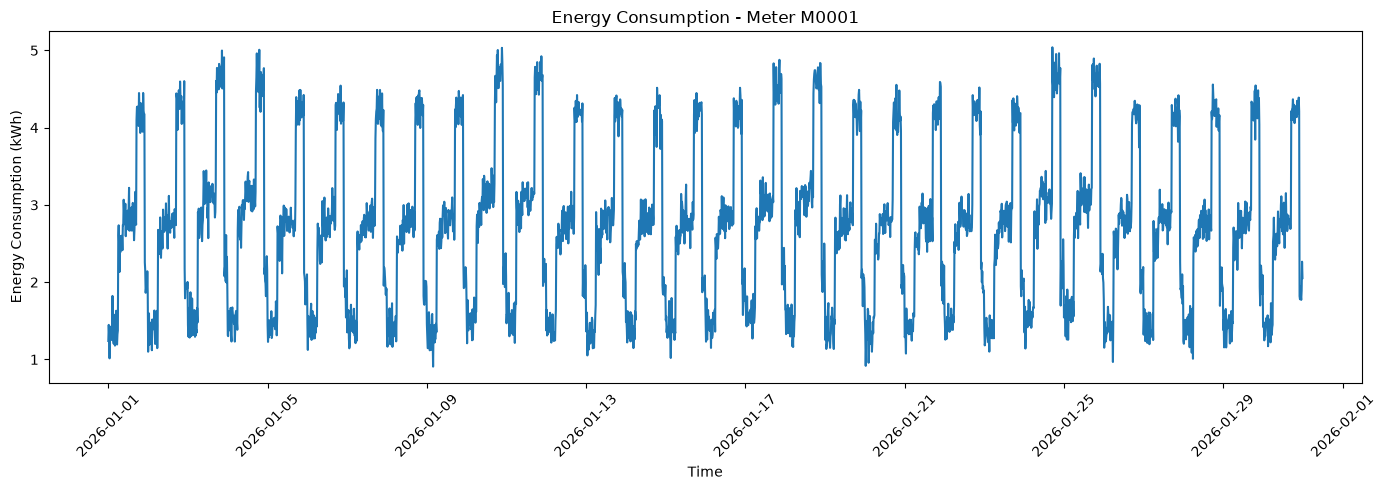

In [7]:
import matplotlib.pyplot as plt

meter = df[df["meter_id"] == "M0001"].copy()

meter["timestamp"] = pd.to_datetime(meter["timestamp"])

plt.figure(figsize=(14, 5))

plt.plot(
    meter["timestamp"],
    meter["energy_kwh"]
)

plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Energy Consumption - Meter M0001")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nNumber of meters:")
print(df["meter_id"].nunique())

print("\nTime range:")
print(df["timestamp"].min())
print(df["timestamp"].max())

Missing values:
meter_id        0
timestamp       0
energy_kwh      0
voltage         0
current         0
power_factor    0
dtype: int64

Duplicate rows:
0

Number of meters:
100

Time range:
2026-01-01 00:00:00
2026-01-30 23:45:00


In [12]:
messy_df = pd.read_csv(
    "../data/raw/smart_meter_readings_messy.csv"
)
messy_df.shape


(289440, 6)

In [13]:
messy_df.isnull().sum()

meter_id           0
timestamp          0
energy_kwh      4316
voltage            0
current            0
power_factor       0
dtype: int64

In [14]:
messy_df.duplicated().sum()

np.int64(1436)

In [15]:
messy_df[messy_df["energy_kwh"] < 0].shape

(100, 6)

In [16]:
messy_df[messy_df["voltage"] > 300].shape

(100, 6)

In [25]:
messy_df[messy_df["energy_kwh"] > 20].shape

(100, 6)

In [26]:
from src.preprocessing.data_quality import validate_meter_data

In [27]:
quality_report = validate_meter_data(messy_df)

quality_report

{'total_rows': 289440,
 'total_meters': 100,
 'missing_values': {'meter_id': 0,
  'timestamp': 0,
  'energy_kwh': 4316,
  'voltage': 0,
  'current': 0,
  'power_factor': 0},
 'duplicate_rows': 1436,
 'negative_energy': 100,
 'invalid_voltage': 100,
 'extreme_energy': 100}

In [28]:
from src.preprocessing.data_cleaning import clean_meter_data

In [29]:
clean_df = clean_meter_data(messy_df)

In [30]:
clean_df.shape

(288004, 7)

In [31]:
clean_df.isnull().sum()

meter_id               0
timestamp              0
energy_kwh             0
voltage              100
current                0
power_factor           0
potential_anomaly      0
dtype: int64

In [32]:
clean_df["potential_anomaly"].value_counts()

potential_anomaly
False    287904
True        100
Name: count, dtype: int64

In [33]:
clean_df["timestamp"] = pd.to_datetime(clean_df["timestamp"])

clean_df.dtypes

meter_id                        str
timestamp            datetime64[us]
energy_kwh                  float64
voltage                     float64
current                     float64
power_factor                float64
potential_anomaly              bool
dtype: object

In [34]:
clean_df["hour"] = clean_df["timestamp"].dt.hour
clean_df["day_of_week"] = clean_df["timestamp"].dt.dayofweek
clean_df["date"] = clean_df["timestamp"].dt.date

In [35]:
hourly_usage = (
    clean_df
    .groupby("hour")["energy_kwh"]
    .mean()
)

hourly_usage

hour
0     1.699038
1     1.730254
2     1.693130
3     1.689039
4     1.689823
5     1.700550
6     3.020408
7     3.024722
8     3.023134
9     3.334375
10    3.339317
11    3.334855
12    3.335382
13    3.360567
14    3.333542
15    3.338017
16    3.349712
17    4.999738
18    4.966248
19    4.993290
20    5.016471
21    4.972530
22    2.372271
23    2.366197
Name: energy_kwh, dtype: float64

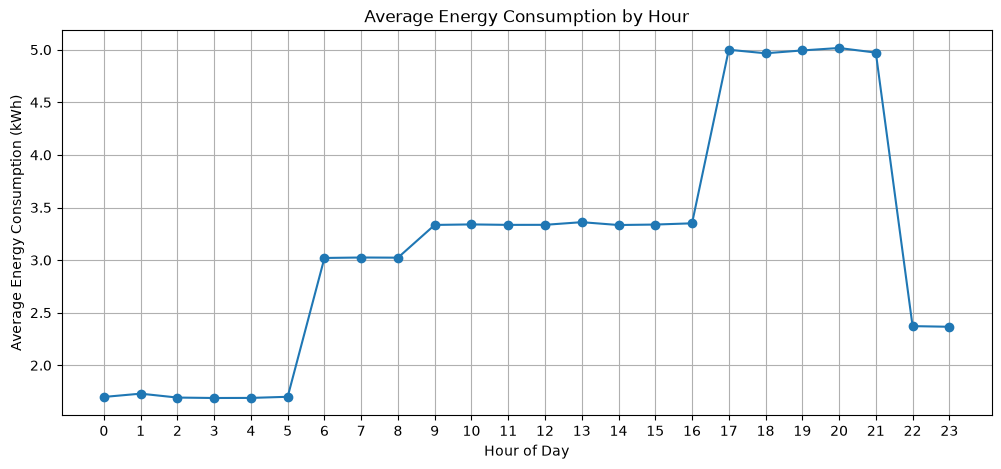

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_usage.index,
    hourly_usage.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Hour")

plt.xticks(range(24))
plt.grid(True)

plt.show()

In [37]:
day_usage = (
    clean_df
    .groupby("day_of_week")["energy_kwh"]
    .mean()
)

day_usage

day_of_week
0    3.060575
1    3.065394
2    3.066327
3    3.093594
4    3.058803
5    3.382913
6    3.384970
Name: energy_kwh, dtype: float64

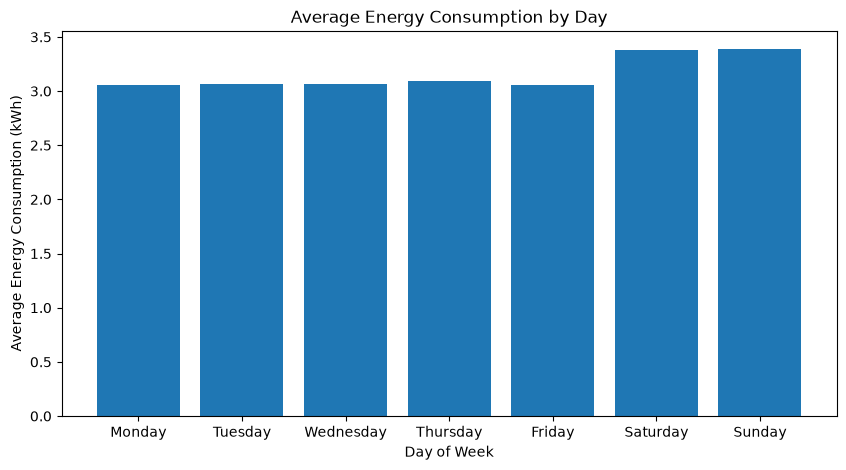

In [38]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_usage.index,
    day_usage.values
)

plt.xlabel("Day of Week")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Day")

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday",
     "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.show()

In [39]:
daily_usage = (
    clean_df
    .groupby(["meter_id", "date"])["energy_kwh"]
    .sum()
    .reset_index()
)

daily_usage.head()

,meter_id,date,energy_kwh
0,M0001,2026-01-01,254.1955
1,M0001,2026-01-02,253.6870
2,M0001,2026-01-03,278.6535
3,M0001,2026-01-04,277.7165
4,M0001,2026-01-05,254.5710


In [40]:
daily_usage.shape

(3000, 3)

In [41]:
meter_usage = (
    clean_df
    .groupby("meter_id")["energy_kwh"]
    .mean()
    .sort_values(ascending=False)
)

meter_usage.head(10)

meter_id
M0068    4.815889
M0022    4.781283
M0071    4.692958
M0083    4.646998
M0047    4.586932
M0054    4.565639
M0048    4.537874
M0078    4.536660
M0055    4.508601
M0098    4.496100
Name: energy_kwh, dtype: float64

In [42]:
meter_usage.tail(10)

meter_id
M0046    1.676386
M0002    1.670068
M0065    1.664893
M0096    1.661005
M0059    1.647431
M0025    1.646649
M0084    1.618074
M0049    1.573098
M0095    1.559353
M0015    1.491259
Name: energy_kwh, dtype: float64

In [43]:
clean_df = clean_df.sort_values(
    ["meter_id", "timestamp"]
).copy()

In [44]:
clean_df["lag_1"] = (
    clean_df.groupby("meter_id")["energy_kwh"]
    .shift(1)
)

clean_df["lag_4"] = (
    clean_df.groupby("meter_id")["energy_kwh"]
    .shift(4)
)

clean_df["lag_96"] = (
    clean_df.groupby("meter_id")["energy_kwh"]
    .shift(96)
)

In [45]:
clean_df["rolling_mean_4"] = (
    clean_df.groupby("meter_id")["energy_kwh"]
    .transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
)

clean_df["rolling_mean_96"] = (
    clean_df.groupby("meter_id")["energy_kwh"]
    .transform(
        lambda x: x.shift(1).rolling(96).mean()
    )
)

In [46]:
clean_df[
    [
        "meter_id",
        "timestamp",
        "energy_kwh",
        "lag_1",
        "lag_4",
        "lag_96",
        "rolling_mean_4",
        "rolling_mean_96"
    ]
].head(110)

,meter_id,timestamp,energy_kwh,lag_1,lag_4,lag_96,rolling_mean_4,rolling_mean_96
0,M0001,2026-01-01 00:00:00,1.239,NaN,NaN,NaN,NaN,NaN
1,M0001,2026-01-01 00:15:00,1.447,1.239,NaN,NaN,NaN,NaN
2,M0001,2026-01-01 00:30:00,1.318,1.447,NaN,NaN,NaN,NaN
3,M0001,2026-01-01 00:45:00,1.014,1.318,NaN,NaN,NaN,NaN
4,M0001,2026-01-01 01:00:00,1.341,1.014,1.239,NaN,1.25450,NaN
...,...,...,...,...,...,...,...,...
105,M0001,2026-01-02 02:15:00,1.119,1.382,1.476,1.371,1.39700,2.653995
106,M0001,2026-01-02 02:30:00,1.517,1.119,1.341,1.822,1.30775,2.651370
107,M0001,2026-01-02 02:45:00,1.394,1.517,1.389,1.438,1.35175,2.648193
108,M0001,2026-01-02 03:00:00,1.450,1.394,1.382,1.254,1.35300,2.647734


In [47]:
meter_df = clean_df[
    clean_df["meter_id"] == "M0001"
].copy()

meter_df = meter_df.sort_values("timestamp")

In [48]:
model_df = meter_df.dropna(
    subset=[
        "lag_1",
        "lag_4",
        "lag_96",
        "rolling_mean_4",
        "rolling_mean_96"
    ]
).copy()

In [49]:
model_df.shape

(2784, 15)

In [50]:
features = [
    "hour",
    "day_of_week",
    "lag_1",
    "lag_4",
    "lag_96",
    "rolling_mean_4",
    "rolling_mean_96"
]

In [51]:
target = "energy_kwh"

In [52]:
split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index]
test_df = model_df.iloc[split_index:]

In [53]:
print("Train:", train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Test :", test_df["timestamp"].min(), "→", test_df["timestamp"].max())

Train: 2026-01-02 00:00:00 → 2026-01-25 04:30:00
Test : 2026-01-25 04:45:00 → 2026-01-30 23:45:00


In [54]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [55]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (2227, 7)
X_test : (557, 7)


In [56]:
from xgboost import XGBRegressor

In [57]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [58]:
model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [59]:
y_pred = model.predict(X_test)

In [60]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1.810,1.499789
1,1.655,1.581623
2,1.495,1.501782
3,1.756,1.415256
4,1.557,2.738869
5,2.593,2.803339
6,2.848,2.842768
7,2.574,2.823750
8,2.755,2.867207
9,2.839,2.860166


In [61]:
# Evaluate the model

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.1291063168369889
RMSE: 0.16934424609458532
R²  : 0.9712176273239584


In [63]:
baseline_pred = test_df["lag_96"]

In [64]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²  :", baseline_r2)

Baseline MAE : 0.19496947935368042
Baseline RMSE: 0.24974940402629617
Baseline R²  : 0.9373970752764635


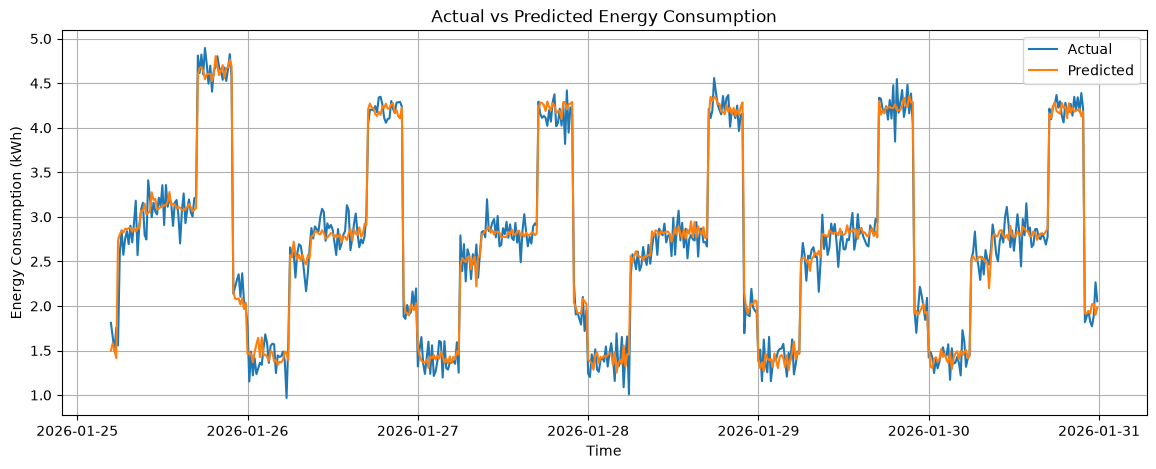

In [65]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_df["timestamp"],
    y_test.values,
    label="Actual"
)

plt.plot(
    test_df["timestamp"],
    y_pred,
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption")

plt.legend()
plt.grid(True)

plt.show()

In [66]:
results = test_df[
    ["timestamp", "energy_kwh", "lag_96"]
].copy()

results["predicted"] = y_pred

results["error"] = (
    results["energy_kwh"] - results["predicted"]
)

results["absolute_error"] = (
    results["error"].abs()
)

results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,timestamp,energy_kwh,lag_96,predicted,error,absolute_error
2327,2026-01-25 05:45:00,1.557,2.280,2.738869,-1.181869,1.181869
2422,2026-01-26 05:30:00,0.967,1.756,1.465914,-0.498914,0.498914
2529,2026-01-27 08:15:00,2.690,2.166,2.218916,0.471084,0.471084
2579,2026-01-27 20:45:00,3.818,4.166,4.288356,-0.470356,0.470356
2612,2026-01-28 05:00:00,1.088,1.380,1.557787,-0.469787,0.469787
2722,2026-01-29 08:30:00,2.159,2.685,2.617695,-0.458695,0.458695
2680,2026-01-28 22:00:00,1.694,2.259,2.150426,-0.456426,0.456426
2615,2026-01-28 05:45:00,1.009,1.251,1.452918,-0.443918,0.443918
2608,2026-01-28 04:00:00,1.692,1.302,1.252669,0.439331,0.439331
2765,2026-01-29 19:15:00,3.845,4.189,4.264738,-0.419738,0.419738


In [67]:
# Anomaly Detection

In [69]:
# Prepare anomaly data 

anomaly_df = clean_df[
    clean_df["meter_id"] == "M0001"
].copy()

anomaly_df = anomaly_df.sort_values("timestamp")

In [70]:
# select the meter readings

anomaly_features = [
    "energy_kwh",
    "voltage",
    "current",
    "power_factor"
]

In [71]:
anomaly_df[anomaly_features].describe()

,energy_kwh,voltage,current,power_factor
count,2880.000000,2879.000000,2880.000000,2880.000000
mean,2.716559,229.963185,5.423299,0.918618
std,1.021437,2.980880,2.217505,0.040441
min,0.907000,219.380000,1.530000,0.850000
25%,1.779500,227.945000,3.590000,0.883000
50%,2.731000,229.980000,5.175000,0.918000
75%,3.142000,232.000000,6.770000,0.953000
max,5.040000,240.190000,12.260000,0.990000


In [72]:
# train isolated forest 

from sklearn.ensemble import IsolationForest

In [73]:
iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

In [74]:
iso_model.fit(
    anomaly_df[anomaly_features]
)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [75]:
anomaly_df["anomaly_score"] = iso_model.decision_function(
    anomaly_df[anomaly_features]
)

In [76]:
anomaly_df["anomaly_flag"] = iso_model.predict(
    anomaly_df[anomaly_features]
)

In [77]:
anomaly_df["is_anomaly"] = (
    anomaly_df["anomaly_flag"] == -1
)

In [78]:
anomalies = anomaly_df[
    anomaly_df["is_anomaly"] == True
]

anomalies[
    [
        "timestamp",
        "energy_kwh",
        "voltage",
        "current",
        "power_factor",
        "anomaly_score"
    ]
].head(20)

,timestamp,energy_kwh,voltage,current,power_factor,anomaly_score
169,2026-01-02 18:15:00,4.2430,237.93,8.96,0.853,-0.027203
175,2026-01-02 19:45:00,4.3440,223.04,10.51,0.898,-0.002167
272,2026-01-03 20:00:00,4.7910,226.72,11.31,0.959,-0.001873
274,2026-01-03 20:30:00,4.9980,229.93,11.01,0.928,-0.006581
278,2026-01-03 21:30:00,4.6790,227.60,10.32,0.854,-0.003821
279,2026-01-03 21:45:00,4.9100,231.07,11.64,0.950,-0.006581
358,2026-01-04 17:30:00,4.9610,226.61,10.00,0.979,-0.017249
364,2026-01-04 19:00:00,5.0080,229.10,11.34,0.874,-0.010817
749,2026-01-08 19:15:00,4.4610,235.26,11.11,0.956,-0.008331
760,2026-01-08 22:00:00,1.8210,239.19,3.46,0.872,-0.004184


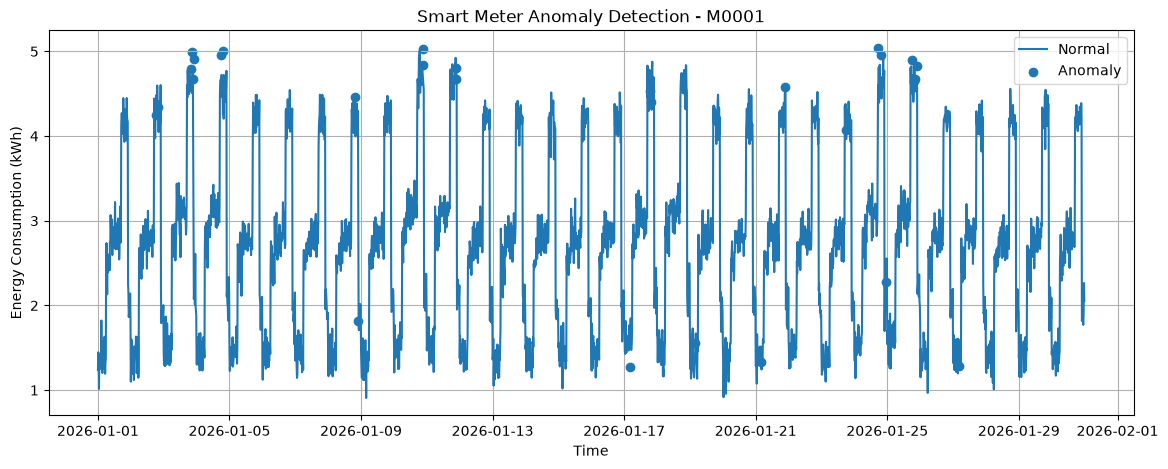

In [79]:
plt.figure(figsize=(14, 5))

normal = anomaly_df[
    ~anomaly_df["is_anomaly"]
]

anomalies = anomaly_df[
    anomaly_df["is_anomaly"]
]

plt.plot(
    normal["timestamp"],
    normal["energy_kwh"],
    label="Normal"
)

plt.scatter(
    anomalies["timestamp"],
    anomalies["energy_kwh"],
    label="Anomaly"
)

plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Smart Meter Anomaly Detection - M0001")

plt.legend()
plt.grid(True)

plt.show()

In [80]:
print("Total readings:", len(anomaly_df))
print("Detected anomalies:", anomaly_df["is_anomaly"].sum())

print(
    "Anomaly percentage:",
    anomaly_df["is_anomaly"].mean() * 100
)

Total readings: 2880
Detected anomalies: 29
Anomaly percentage: 1.0069444444444444


In [81]:
results["residual"] = (
    results["energy_kwh"] - results["predicted"]
)

results["absolute_residual"] = (
    results["residual"].abs()
)

In [82]:
results.sort_values(
    "absolute_residual",
    ascending=False
).head(10)

,timestamp,energy_kwh,lag_96,predicted,error,absolute_error,residual,absolute_residual
2327,2026-01-25 05:45:00,1.557,2.280,2.738869,-1.181869,1.181869,-1.181869,1.181869
2422,2026-01-26 05:30:00,0.967,1.756,1.465914,-0.498914,0.498914,-0.498914,0.498914
2529,2026-01-27 08:15:00,2.690,2.166,2.218916,0.471084,0.471084,0.471084,0.471084
2579,2026-01-27 20:45:00,3.818,4.166,4.288356,-0.470356,0.470356,-0.470356,0.470356
2612,2026-01-28 05:00:00,1.088,1.380,1.557787,-0.469787,0.469787,-0.469787,0.469787
2722,2026-01-29 08:30:00,2.159,2.685,2.617695,-0.458695,0.458695,-0.458695,0.458695
2680,2026-01-28 22:00:00,1.694,2.259,2.150426,-0.456426,0.456426,-0.456426,0.456426
2615,2026-01-28 05:45:00,1.009,1.251,1.452918,-0.443918,0.443918,-0.443918,0.443918
2608,2026-01-28 04:00:00,1.692,1.302,1.252669,0.439331,0.439331,0.439331,0.439331
2765,2026-01-29 19:15:00,3.845,4.189,4.264738,-0.419738,0.419738,-0.419738,0.419738


In [83]:
train_pred = model.predict(X_train)

In [84]:
train_residuals = (
    y_train.values - train_pred
)

train_abs_residuals = np.abs(
    train_residuals
)

In [85]:
pd.Series(train_abs_residuals).describe()

count    2227.000000
mean        0.066148
std         0.056023
min         0.000005
25%         0.023871
50%         0.051620
75%         0.093048
max         0.351782
dtype: float64

In [86]:
threshold = np.percentile(
    train_abs_residuals,
    95
)

print("Residual threshold:", threshold)

Residual threshold: 0.18110313148498516


In [87]:
results["residual_anomaly"] = (
    results["absolute_residual"] > threshold
)

In [88]:
residual_anomalies = results[
    results["residual_anomaly"]
]

In [89]:
print(
    "Residual anomalies:",
    len(residual_anomalies)
)

print(
    "Percentage:",
    len(residual_anomalies) / len(results) * 100
)

Residual anomalies: 140
Percentage: 25.134649910233392


In [90]:
threshold_99 = np.percentile(
    train_abs_residuals,
    99
)

print("99% threshold:", threshold_99)

99% threshold: 0.2334893010330199


In [91]:
threshold_995 = np.percentile(
    train_abs_residuals,
    99.5
)

print("99.5% threshold:", threshold_995)

99.5% threshold: 0.27858152355193977


In [92]:
for threshold in [threshold, threshold_99, threshold_995]:

    count = (
        results["absolute_residual"] > threshold
    ).sum()

    percentage = count / len(results) * 100

    print(
        f"Threshold: {threshold:.3f} | "
        f"Anomalies: {count} | "
        f"Percentage: {percentage:.2f}%"
    )

Threshold: 0.181 | Anomalies: 140 | Percentage: 25.13%
Threshold: 0.233 | Anomalies: 86 | Percentage: 15.44%
Threshold: 0.279 | Anomalies: 49 | Percentage: 8.80%


In [93]:
dashboard_df = results[
    [
        "timestamp",
        "energy_kwh",
        "predicted",
        "absolute_residual"
    ]
].copy()

dashboard_df.head()

,timestamp,energy_kwh,predicted,absolute_residual
2323,2026-01-25 04:45:00,1.810,1.499789,0.310211
2324,2026-01-25 05:00:00,1.655,1.581623,0.073377
2325,2026-01-25 05:15:00,1.495,1.501782,0.006782
2326,2026-01-25 05:30:00,1.756,1.415256,0.340744
2327,2026-01-25 05:45:00,1.557,2.738869,1.181869


In [94]:
dashboard_df = dashboard_df.rename(
    columns={
        "energy_kwh": "actual_energy",
        "predicted": "expected_energy",
        "absolute_residual": "prediction_error"
    }
)

dashboard_df.head()

,timestamp,actual_energy,expected_energy,prediction_error
2323,2026-01-25 04:45:00,1.810,1.499789,0.310211
2324,2026-01-25 05:00:00,1.655,1.581623,0.073377
2325,2026-01-25 05:15:00,1.495,1.501782,0.006782
2326,2026-01-25 05:30:00,1.756,1.415256,0.340744
2327,2026-01-25 05:45:00,1.557,2.738869,1.181869


In [95]:
anomaly_df.columns

Index(['meter_id', 'timestamp', 'energy_kwh', 'voltage', 'current',
       'power_factor', 'potential_anomaly', 'hour', 'day_of_week', 'date',
       'lag_1', 'lag_4', 'lag_96', 'rolling_mean_4', 'rolling_mean_96',
       'anomaly_score', 'anomaly_flag', 'is_anomaly'],
      dtype='str')

In [96]:
dashboard_df = dashboard_df.merge(
    anomaly_df[
        [
            "timestamp",
            "anomaly_score",
            "is_anomaly"
        ]
    ],
    on="timestamp",
    how="left"
)

dashboard_df.head()

,timestamp,actual_energy,expected_energy,prediction_error,anomaly_score,is_anomaly
0,2026-01-25 04:45:00,1.810,1.499789,0.310211,0.126698,False
1,2026-01-25 05:00:00,1.655,1.581623,0.073377,0.098242,False
2,2026-01-25 05:15:00,1.495,1.501782,0.006782,0.111503,False
3,2026-01-25 05:30:00,1.756,1.415256,0.340744,0.009906,False
4,2026-01-25 05:45:00,1.557,2.738869,1.181869,0.130532,False


In [97]:
dashboard_df["is_anomaly"].value_counts()

is_anomaly
False    552
True       5
Name: count, dtype: int64

In [98]:
dashboard_df["is_anomaly"].mean() * 100

np.float64(0.8976660682226212)

In [99]:
dashboard_df["status"] = dashboard_df["is_anomaly"].map(
    {
        True: "Anomaly",
        False: "Normal"
    }
)

In [100]:
dashboard_df.head()

,timestamp,actual_energy,expected_energy,prediction_error,anomaly_score,is_anomaly,status
0,2026-01-25 04:45:00,1.810,1.499789,0.310211,0.126698,False,Normal
1,2026-01-25 05:00:00,1.655,1.581623,0.073377,0.098242,False,Normal
2,2026-01-25 05:15:00,1.495,1.501782,0.006782,0.111503,False,Normal
3,2026-01-25 05:30:00,1.756,1.415256,0.340744,0.009906,False,Normal
4,2026-01-25 05:45:00,1.557,2.738869,1.181869,0.130532,False,Normal


In [102]:
dashboard_df.to_csv(
    "../data/processed/dashboard_results.csv",
    index=False
)

In [103]:
print(type(model))
print(model.feature_names_in_)

<class 'xgboost.sklearn.XGBRegressor'>
['hour' 'day_of_week' 'lag_1' 'lag_4' 'lag_96' 'rolling_mean_4'
 'rolling_mean_96']


In [107]:
from pathlib import Path
import joblib

project_root = Path.cwd().parent

model_path = project_root / "models" / "energy_forecasting_model.pkl"

joblib.dump(model, model_path)

print("Model saved to:", model_path)

Model saved to: c:\projects\ML\smartmeter-ai\models\energy_forecasting_model.pkl


In [108]:
model_path.exists()

True

In [109]:
import joblib
from pathlib import Path

threshold_path = Path("../models/anomaly_threshold.pkl")

joblib.dump(threshold_99, threshold_path)

print("Anomaly threshold saved to:", threshold_path)

Anomaly threshold saved to: ..\models\anomaly_threshold.pkl


In [110]:
loaded_threshold = joblib.load(threshold_path)

print("Loaded threshold:", loaded_threshold)

Loaded threshold: 0.2334893010330199


In [111]:
results.columns

Index(['timestamp', 'energy_kwh', 'lag_96', 'predicted', 'error',
       'absolute_error', 'residual', 'absolute_residual', 'residual_anomaly'],
      dtype='str')

In [112]:
results["meter_id"] = model_df.loc[results.index, "meter_id"].values

In [113]:
results[["meter_id", "timestamp", "energy_kwh", "predicted"]].head()

,meter_id,timestamp,energy_kwh,predicted
2323,M0001,2026-01-25 04:45:00,1.810,1.499789
2324,M0001,2026-01-25 05:00:00,1.655,1.581623
2325,M0001,2026-01-25 05:15:00,1.495,1.501782
2326,M0001,2026-01-25 05:30:00,1.756,1.415256
2327,M0001,2026-01-25 05:45:00,1.557,2.738869


In [114]:
dashboard_df = results[
    [
        "meter_id",
        "timestamp",
        "energy_kwh",
        "predicted",
        "absolute_residual",
        "residual_anomaly"
    ]
].copy()

In [115]:
dashboard_df = dashboard_df.rename(
    columns={
        "energy_kwh": "actual_energy",
        "predicted": "expected_energy",
        "absolute_residual": "prediction_error",
        "residual_anomaly": "is_anomaly"
    }
)

In [116]:
dashboard_df.head()

,meter_id,timestamp,actual_energy,expected_energy,prediction_error,is_anomaly
2323,M0001,2026-01-25 04:45:00,1.810,1.499789,0.310211,True
2324,M0001,2026-01-25 05:00:00,1.655,1.581623,0.073377,False
2325,M0001,2026-01-25 05:15:00,1.495,1.501782,0.006782,False
2326,M0001,2026-01-25 05:30:00,1.756,1.415256,0.340744,True
2327,M0001,2026-01-25 05:45:00,1.557,2.738869,1.181869,True


In [117]:
dashboard_df.to_csv(
    "../data/processed/dashboard_results.csv",
    index=False
)

In [118]:
pd.read_csv(
    "../data/processed/dashboard_results.csv"
).columns

Index(['meter_id', 'timestamp', 'actual_energy', 'expected_energy',
       'prediction_error', 'is_anomaly'],
      dtype='str')